# Generative AI Tools & Platforms 2025 — EDA and Baseline Modeling

A practical analysis of a 2025 GenAI tools catalog, covering data quality, category structure, modality coverage, API availability, open-source patterns, and a simple baseline model.

## Overview and Goals

This notebook answers a few practical questions:

- What does the dataset contain, and is it internally consistent?
- Which categories, modalities, release years, and API patterns dominate this catalog?
- How does open-source availability vary by category and modality?
- Can simple metadata predict `open_source` without leaking identifiers?

The analysis starts with data quality checks, fixes the inconsistent `modality_count` field, avoids unsupported co-occurrence claims, and uses a simple baseline model to test whether metadata carries useful signal.

## Config and Imports

In [59]:
from pathlib import Path
from io import StringIO
import warnings

from IPython.display import Markdown, display

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_SEED = 42
REFERENCE_YEAR = 2025
TARGET = "open_source"
DATA_FILENAME = "Generative AI Tools - Platforms 2025.csv"

PRIMARY_COLOR = "#4C78A8"

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.3f}".format)

print("Setup complete.")

Setup complete.


## Data Loading

The loader checks common Kaggle paths first, then local paths. This keeps the notebook portable between Kaggle and a GitHub/local workflow.

In [60]:
def find_data_file(filename: str = DATA_FILENAME) -> Path:
    """Find the dataset file across Kaggle and local execution environments."""
    candidate_paths = [
        Path("/kaggle/input/generative-ai-tools-and-platforms-2025") / filename,
        Path("/kaggle/input/generative-ai-tools-platforms-2025") / filename,
        Path("/kaggle/input") / filename,
        Path("/mnt/data/genai_dataset") / filename,
        Path("data/raw") / filename,
        Path(filename),
    ]

    for path in candidate_paths:
        if path.exists():
            return path

    for root in [Path("/kaggle/input"), Path("/mnt/data"), Path("data"), Path(".")]:
        if root.exists():
            matches = list(root.rglob(filename))
            if matches:
                return matches[0]

    raise FileNotFoundError(
        f"Could not find {filename}. Attach the dataset on Kaggle or place it under data/raw/."
    )


DATA_PATH = find_data_file()
df_raw = pd.read_csv(DATA_PATH)

print(f"Loaded file: {DATA_PATH}")
print(f"Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]:,} columns")
display(df_raw.head(5))

Loaded file: /kaggle/input/generative-ai-tools-and-platforms-2025/Generative AI Tools - Platforms 2025.csv
Shape: 113 rows x 22 columns


,tool_name,company,category_canonical,modality_canonical,open_source,api_available,api_status,website,source_domain,release_year,years_since_release,mod_text,mod_image,mod_video,mod_audio,mod_code,mod_design,mod_infra,mod_productivity,mod_safety,mod_multimodal,modality_count
0,ChatGPT,OpenAI,LLMs & Chat Assistants,multimodal,0,1,api,https://chatgpt.com,chatgpt.com,2022,3,0,0,0,0,0,0,0,0,0,1,0
1,Claude,Anthropic,LLMs & Chat Assistants,multimodal,0,1,api,https://claude.ai,claude.ai,2023,2,0,0,0,0,0,0,0,0,0,1,0
2,Gemini,Google,LLMs & Chat Assistants,multimodal,0,1,api,https://gemini.google.com,gemini.google.com,2023,2,0,0,0,0,0,0,0,0,0,1,0
3,Midjourney,Midjourney,Image Gen & Editing,image,0,0,unavailable,https://www.midjourney.com,midjourney.com,2022,3,0,1,0,0,0,0,0,0,0,0,1
4,Stable Diffusion,Stability AI,Image Gen & Editing,image,1,1,api,https://stability.ai/stable-image,stability.ai,2022,3,0,1,0,0,0,0,0,0,0,0,1


## Initial Data Audit

Start by checking structure, missingness, duplicates, target balance, and basic field ranges.

In [61]:
def summarize_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """Return a compact schema summary."""
    return pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "non_null": df.notna().sum(),
        "missing": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "unique": df.nunique(dropna=True),
    }).sort_index()


print("Basic shape")
print(f"Rows: {df_raw.shape[0]:,}")
print(f"Columns: {df_raw.shape[1]:,}")

print("\nDataFrame info")
buffer = StringIO()
df_raw.info(buf=buffer)
print(buffer.getvalue())

display(Markdown("### Schema Summary"))
display(summarize_dataframe(df_raw))

display(Markdown("### Numeric Summary"))
display(df_raw.select_dtypes(include=[np.number]).describe().T)

quality_checks = {
    "duplicate_rows": int(df_raw.duplicated().sum()),
    "duplicate_tool_names": int(df_raw["tool_name"].duplicated().sum()) if "tool_name" in df_raw.columns else np.nan,
    "missing_cells": int(df_raw.isna().sum().sum()),
    "release_year_min": int(df_raw["release_year"].min()) if "release_year" in df_raw.columns else np.nan,
    "release_year_max": int(df_raw["release_year"].max()) if "release_year" in df_raw.columns else np.nan,
}

display(Markdown("### Data Quality Checks"))
display(pd.DataFrame.from_dict(quality_checks, orient="index", columns=["value"]))

if TARGET in df_raw.columns:
    target_counts = (
        df_raw[TARGET]
        .value_counts(dropna=False)
        .rename_axis(TARGET)
        .reset_index(name="count")
    )
    target_counts["share"] = target_counts["count"] / len(df_raw)
    display(Markdown("### Target Distribution"))
    display(target_counts)

Basic shape
Rows: 113
Columns: 22

DataFrame info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113 entries, 0 to 112
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   tool_name            113 non-null    object
 1   company              113 non-null    object
 2   category_canonical   113 non-null    object
 3   modality_canonical   113 non-null    object
 4   open_source          113 non-null    int64 
 5   api_available        113 non-null    int64 
 6   api_status           113 non-null    object
 7   website              113 non-null    object
 8   source_domain        113 non-null    object
 9   release_year         113 non-null    int64 
 10  years_since_release  113 non-null    int64 
 11  mod_text             113 non-null    int64 
 12  mod_image            113 non-null    int64 
 13  mod_video            113 non-null    int64 
 14  mod_audio            113 non-null    int64 
 15  mod_cod

### Schema Summary

,dtype,non_null,missing,missing_pct,unique
api_available,int64,113,0,0.000,2
api_status,object,113,0,0.000,2
category_canonical,object,113,0,0.000,13
company,object,113,0,0.000,83
mod_audio,int64,113,0,0.000,2
mod_code,int64,113,0,0.000,2
mod_design,int64,113,0,0.000,2
mod_image,int64,113,0,0.000,2
mod_infra,int64,113,0,0.000,2
mod_multimodal,int64,113,0,0.000,2


### Numeric Summary

,count,mean,std,min,25%,50%,75%,max
open_source,113.000,0.372,0.485,0.000,0.000,0.000,1.000,1.000
api_available,113.000,0.947,0.225,0.000,1.000,1.000,1.000,1.000
release_year,113.000,"2,022.204",2.084,"2,013.000","2,022.000","2,023.000","2,023.000","2,025.000"
years_since_release,113.000,2.796,2.084,0.000,2.000,2.000,3.000,12.000
mod_text,113.000,0.027,0.161,0.000,0.000,0.000,0.000,1.000
mod_image,113.000,0.124,0.331,0.000,0.000,0.000,0.000,1.000
mod_video,113.000,0.071,0.258,0.000,0.000,0.000,0.000,1.000
mod_audio,113.000,0.124,0.331,0.000,0.000,0.000,0.000,1.000
mod_code,113.000,0.168,0.376,0.000,0.000,0.000,0.000,1.000
mod_design,113.000,0.027,0.161,0.000,0.000,0.000,0.000,1.000


### Data Quality Checks

,value
duplicate_rows,0
duplicate_tool_names,0
missing_cells,0
release_year_min,2013
release_year_max,2025


### Target Distribution

,open_source,count,share
0,0,71,0.628
1,1,42,0.372


## Cleaning and Derived Features

The original `modality_count` is preserved for audit, but analysis uses a recomputed count from the active `mod_*` flags. This avoids misleading modality-diversity claims.

In [62]:
def clean_and_engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Clean text fields, enforce binary columns, and add reliable derived features."""
    clean = df.copy()

    for col in clean.select_dtypes(include="object").columns:
        clean[col] = clean[col].astype(str).str.strip()

    binary_cols = [
        "open_source",
        "api_available",
        "mod_text",
        "mod_image",
        "mod_video",
        "mod_audio",
        "mod_code",
        "mod_design",
        "mod_infra",
        "mod_productivity",
        "mod_safety",
        "mod_multimodal",
    ]

    for col in binary_cols:
        if col in clean.columns:
            clean[col] = pd.to_numeric(clean[col], errors="coerce").fillna(0).astype(int)

    if "release_year" in clean.columns:
        clean["release_year"] = pd.to_numeric(clean["release_year"], errors="coerce").astype(int)
        clean["years_since_release_2025"] = (REFERENCE_YEAR - clean["release_year"]).clip(lower=0).astype(int)
        clean["is_recent_release"] = (clean["release_year"] >= 2022).astype(int)

    mod_cols = [
        col for col in clean.columns
        if col.startswith("mod_") and col != "modality_count"
    ]

    if "modality_count" in clean.columns:
        clean["modality_count_original"] = clean["modality_count"]

    clean["modality_count_recomputed"] = clean[mod_cols].sum(axis=1).astype(int)

    return clean


df = clean_and_engineer_features(df_raw)

mod_cols = [
    col for col in df.columns
    if col.startswith("mod_") and col != "modality_count"
]

if "modality_count_original" in df.columns:
    mismatch_mask = df["modality_count_original"] != df["modality_count_recomputed"]
    mismatch_count = int(mismatch_mask.sum())
    mismatch_rate = mismatch_count / len(df)

    display(Markdown(
        f"**Modality count audit:** {mismatch_count:,} rows "
        f"({mismatch_rate:.1%}) differ between the original `modality_count` and the recomputed flag sum."
    ))

    mismatch_cols = [
        "tool_name",
        "category_canonical",
        "modality_canonical",
        "modality_count_original",
        "modality_count_recomputed",
    ] + mod_cols

    display(df.loc[mismatch_mask, mismatch_cols].head(10))

print(f"Cleaned shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
display(df.head(5))

**Modality count audit:** 55 rows (48.7%) differ between the original `modality_count` and the recomputed flag sum.

,tool_name,category_canonical,modality_canonical,modality_count_original,modality_count_recomputed,mod_text,mod_image,mod_video,mod_audio,mod_code,mod_design,mod_infra,mod_productivity,mod_safety,mod_multimodal
0,ChatGPT,LLMs & Chat Assistants,multimodal,0,1,0,0,0,0,0,0,0,0,0,1
1,Claude,LLMs & Chat Assistants,multimodal,0,1,0,0,0,0,0,0,0,0,0,1
2,Gemini,LLMs & Chat Assistants,multimodal,0,1,0,0,0,0,0,0,0,0,0,1
16,Perplexity,Other,multimodal,0,1,0,0,0,0,0,0,0,0,0,1
17,Meta AI,LLMs & Chat Assistants,multimodal,0,1,0,0,0,0,0,0,0,0,0,1
18,Mistral Le Chat,LLMs & Chat Assistants,multimodal,0,1,0,0,0,0,0,0,0,0,0,1
19,Pinecone,Search & RAG,infra,0,1,0,0,0,0,0,0,1,0,0,0
20,Weaviate,Search & RAG,infra,0,1,0,0,0,0,0,0,1,0,0,0
21,Milvus,Search & RAG,infra,0,1,0,0,0,0,0,0,1,0,0,0
22,Qdrant,Search & RAG,infra,0,1,0,0,0,0,0,0,1,0,0,0


Cleaned shape: 113 rows x 26 columns


,tool_name,company,category_canonical,modality_canonical,open_source,api_available,api_status,website,source_domain,release_year,years_since_release,mod_text,mod_image,mod_video,mod_audio,mod_code,mod_design,mod_infra,mod_productivity,mod_safety,mod_multimodal,modality_count,years_since_release_2025,is_recent_release,modality_count_original,modality_count_recomputed
0,ChatGPT,OpenAI,LLMs & Chat Assistants,multimodal,0,1,api,https://chatgpt.com,chatgpt.com,2022,3,0,0,0,0,0,0,0,0,0,1,0,3,1,0,1
1,Claude,Anthropic,LLMs & Chat Assistants,multimodal,0,1,api,https://claude.ai,claude.ai,2023,2,0,0,0,0,0,0,0,0,0,1,0,2,1,0,1
2,Gemini,Google,LLMs & Chat Assistants,multimodal,0,1,api,https://gemini.google.com,gemini.google.com,2023,2,0,0,0,0,0,0,0,0,0,1,0,2,1,0,1
3,Midjourney,Midjourney,Image Gen & Editing,image,0,0,unavailable,https://www.midjourney.com,midjourney.com,2022,3,0,1,0,0,0,0,0,0,0,0,1,3,1,1,1
4,Stable Diffusion,Stability AI,Image Gen & Editing,image,1,1,api,https://stability.ai/stable-image,stability.ai,2022,3,0,1,0,0,0,0,0,0,0,0,1,3,1,1,1


## Exploratory Data Analysis

The analysis below describes what this specific catalog supports. It avoids general market claims that are not directly backed by the fields in the dataset.

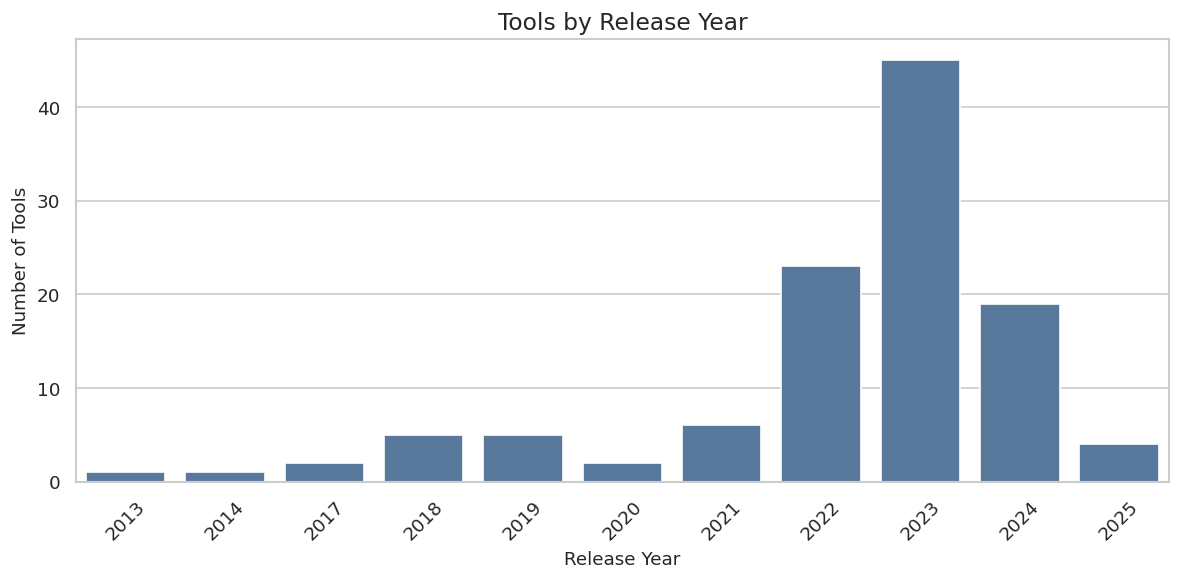

**Insight:** The largest release concentration in this dataset is 2023 with 45 tools. The catalog is weighted toward the post-2022 GenAI wave.

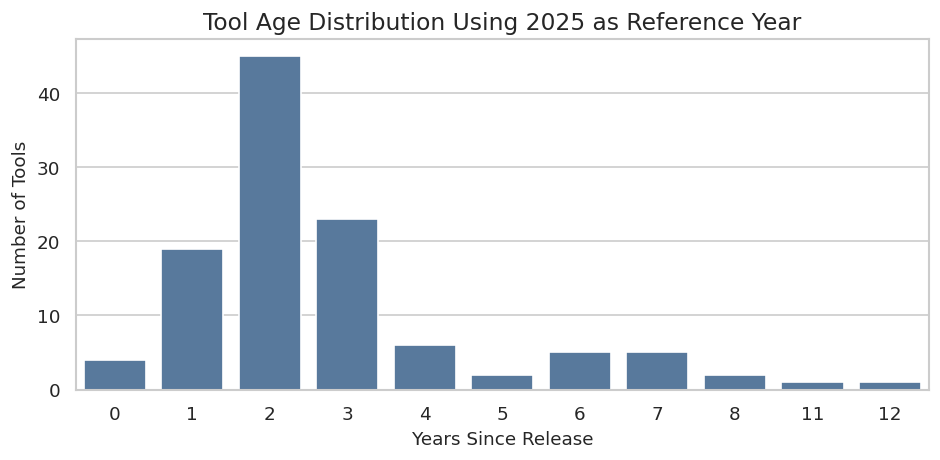

**Insight:** 80.5% of tools were released in 2022 or later.

In [63]:
if "release_year" in df.columns:
    yearly = df["release_year"].value_counts().sort_index()
    peak_year = int(yearly.idxmax())
    peak_count = int(yearly.max())

    plt.figure(figsize=(10, 5))
    ax = sns.barplot(x=yearly.index.astype(str), y=yearly.values, color=PRIMARY_COLOR)
    ax.set_title("Tools by Release Year")
    ax.set_xlabel("Release Year")
    ax.set_ylabel("Number of Tools")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    display(Markdown(
        f"**Insight:** The largest release concentration in this dataset is {peak_year} "
        f"with {peak_count} tools. The catalog is weighted toward the post-2022 GenAI wave."
    ))

if "years_since_release_2025" in df.columns:
    age_counts = df["years_since_release_2025"].value_counts().sort_index()

    plt.figure(figsize=(8, 4))
    ax = sns.barplot(x=age_counts.index.astype(str), y=age_counts.values, color=PRIMARY_COLOR)
    ax.set_title("Tool Age Distribution Using 2025 as Reference Year")
    ax.set_xlabel("Years Since Release")
    ax.set_ylabel("Number of Tools")
    plt.tight_layout()
    plt.show()

    recent_share = df["is_recent_release"].mean()
    display(Markdown(
        f"**Insight:** {recent_share:.1%} of tools were released in 2022 or later."
    ))

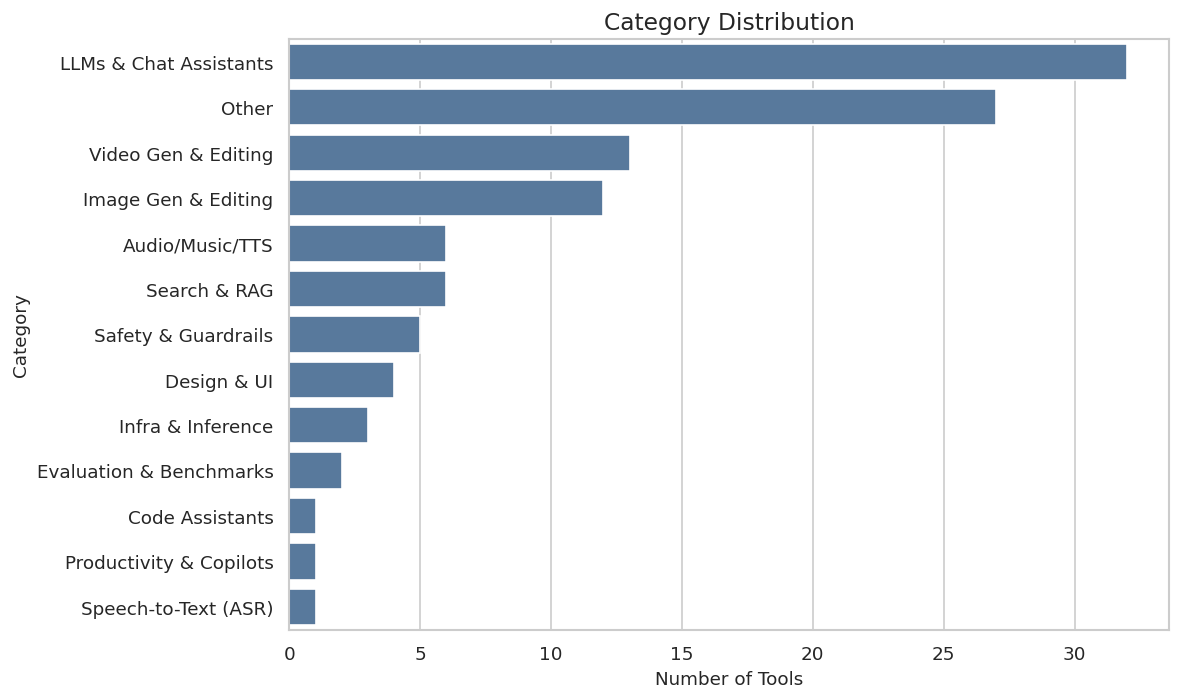

**Insight:** `LLMs & Chat Assistants` is the largest category with 32 tools (28.3% of the dataset).

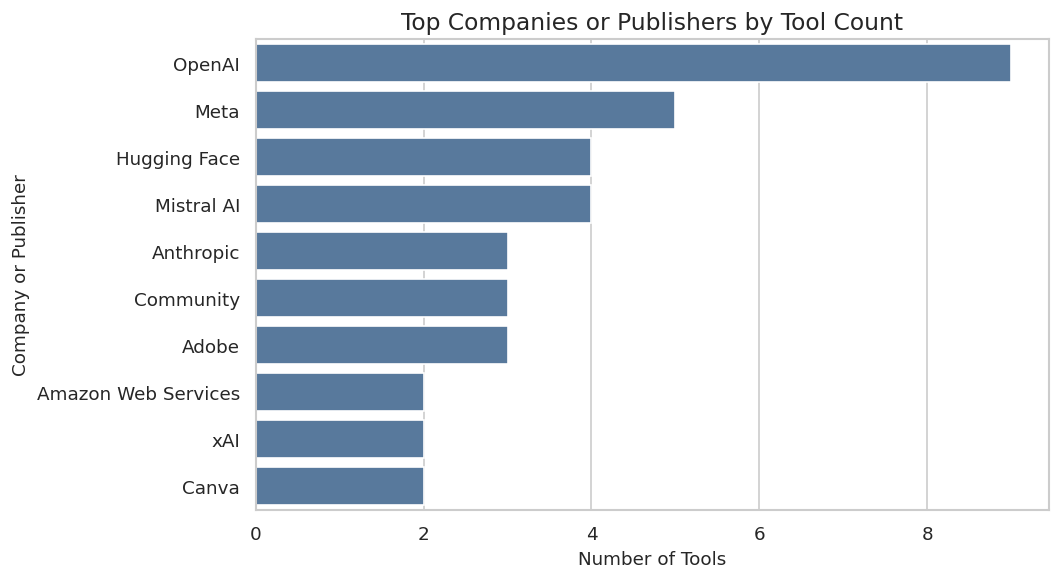

**Insight:** The company distribution is long-tailed. A few publishers appear multiple times, but most entities appear only once.

In [64]:
if "category_canonical" in df.columns:
    category_counts = df["category_canonical"].value_counts()

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(
        x=category_counts.values,
        y=category_counts.index,
        order=category_counts.index,
        color=PRIMARY_COLOR,
    )
    ax.set_title("Category Distribution")
    ax.set_xlabel("Number of Tools")
    ax.set_ylabel("Category")
    plt.tight_layout()
    plt.show()

    top_category = category_counts.index[0]
    top_category_share = category_counts.iloc[0] / len(df)

    display(Markdown(
        f"**Insight:** `{top_category}` is the largest category with "
        f"{category_counts.iloc[0]} tools ({top_category_share:.1%} of the dataset)."
    ))

if "company" in df.columns:
    top_companies = df["company"].value_counts().head(10)

    plt.figure(figsize=(9, 5))
    ax = sns.barplot(x=top_companies.values, y=top_companies.index, color=PRIMARY_COLOR)
    ax.set_title("Top Companies or Publishers by Tool Count")
    ax.set_xlabel("Number of Tools")
    ax.set_ylabel("Company or Publisher")
    plt.tight_layout()
    plt.show()

    display(Markdown(
        "**Insight:** The company distribution is long-tailed. A few publishers appear multiple times, "
        "but most entities appear only once."
    ))

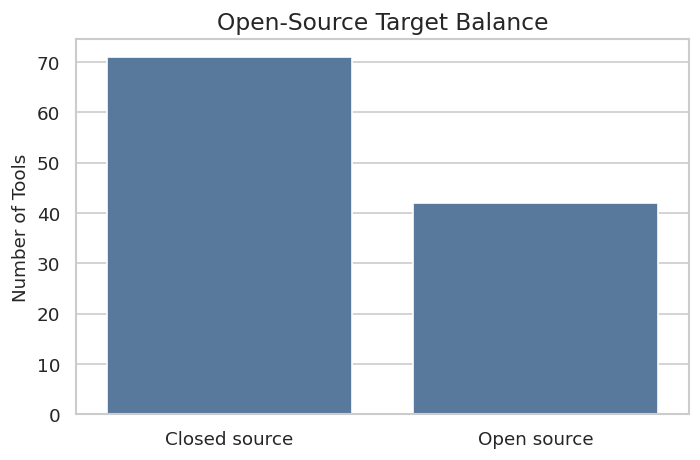

**Insight:** 42 of 113 tools are marked open source (37.2%). Closed-source tools are the majority in this catalog.

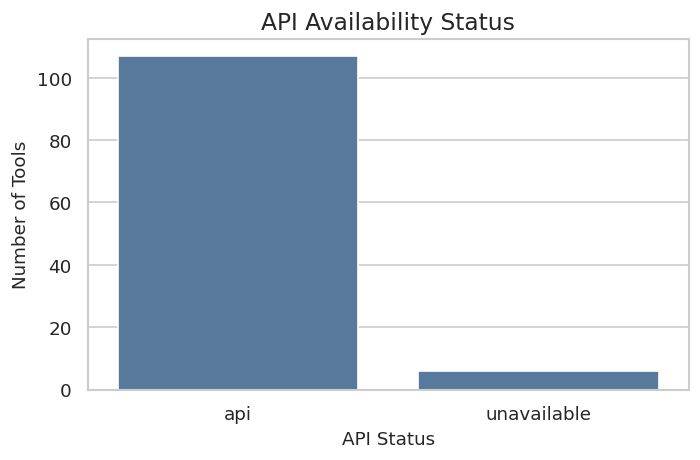

**Insight:** 94.7% of tools are marked as having an API. This dataset is strongly API-heavy.

In [65]:
if TARGET in df.columns:
    open_counts = df[TARGET].value_counts().reindex([0, 1]).fillna(0).astype(int)
    open_share = df[TARGET].mean()

    plt.figure(figsize=(6, 4))
    ax = sns.barplot(
        x=["Closed source", "Open source"],
        y=[open_counts.loc[0], open_counts.loc[1]],
        color=PRIMARY_COLOR,
    )
    ax.set_title("Open-Source Target Balance")
    ax.set_xlabel("")
    ax.set_ylabel("Number of Tools")
    plt.tight_layout()
    plt.show()

    display(Markdown(
        f"**Insight:** {open_counts.loc[1]} of {len(df)} tools are marked open source "
        f"({open_share:.1%}). Closed-source tools are the majority in this catalog."
    ))

if {"api_status", "api_available"}.issubset(df.columns):
    api_counts = df["api_status"].value_counts()

    plt.figure(figsize=(6, 4))
    ax = sns.barplot(x=api_counts.index, y=api_counts.values, color=PRIMARY_COLOR)
    ax.set_title("API Availability Status")
    ax.set_xlabel("API Status")
    ax.set_ylabel("Number of Tools")
    plt.tight_layout()
    plt.show()

    api_share = df["api_available"].mean()
    display(Markdown(
        f"**Insight:** {api_share:.1%} of tools are marked as having an API. "
        "This dataset is strongly API-heavy."
    ))

### Category-Level Summary

,tools,open_source_rate,api_rate
category_canonical,,,
LLMs & Chat Assistants,32,43.8%,100.0%
Other,27,33.3%,96.3%
Video Gen & Editing,13,7.7%,84.6%
Image Gen & Editing,12,33.3%,75.0%
Search & RAG,6,83.3%,100.0%
Audio/Music/TTS,6,33.3%,100.0%
Safety & Guardrails,5,80.0%,100.0%
Design & UI,4,0.0%,100.0%
Infra & Inference,3,33.3%,100.0%


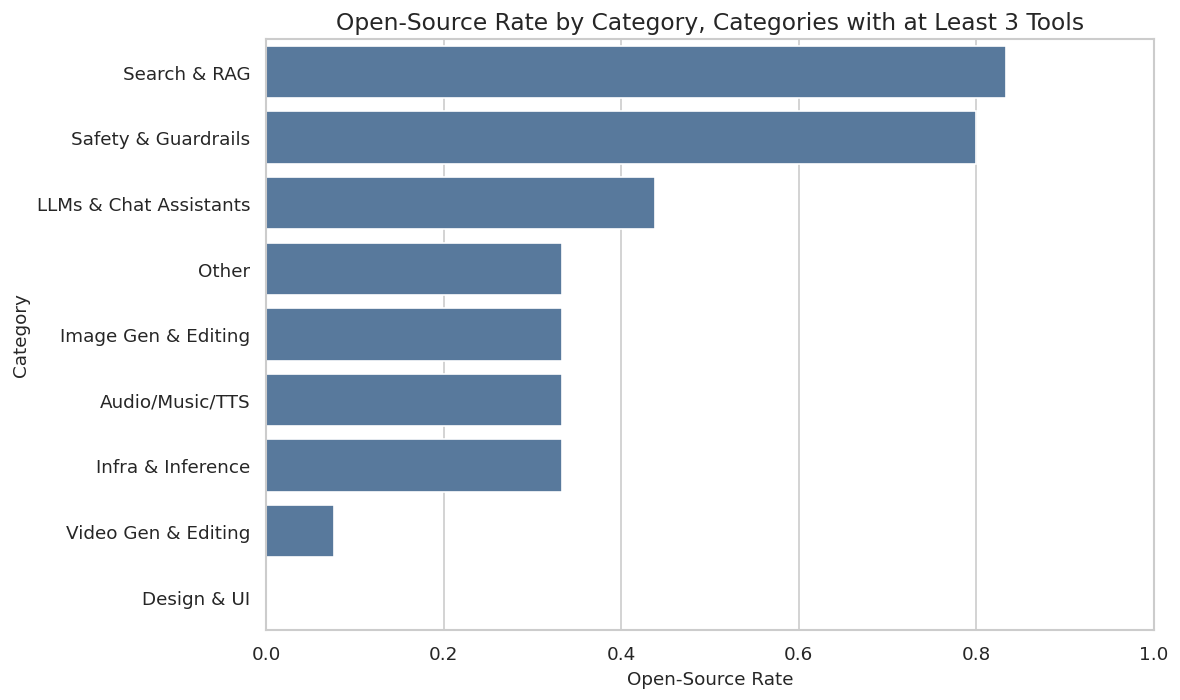

**Insight:** Among categories with at least three tools, `Search & RAG` has the highest open-source rate (83.3%, n=6). Small category sizes should be interpreted carefully.

In [66]:
if "category_canonical" in df.columns and TARGET in df.columns:
    category_summary = (
        df.groupby("category_canonical")
        .agg(
            tools=("tool_name", "count"),
            open_source_rate=(TARGET, "mean"),
            api_rate=("api_available", "mean"),
        )
        .sort_values(["tools", "open_source_rate"], ascending=[False, False])
    )

    display(Markdown("### Category-Level Summary"))
    display(category_summary.style.format({
        "open_source_rate": "{:.1%}",
        "api_rate": "{:.1%}",
    }))

    category_for_rate = category_summary.query("tools >= 3").sort_values("open_source_rate", ascending=False)

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(
        data=category_for_rate.reset_index(),
        x="open_source_rate",
        y="category_canonical",
        color=PRIMARY_COLOR,
    )
    ax.set_title("Open-Source Rate by Category, Categories with at Least 3 Tools")
    ax.set_xlabel("Open-Source Rate")
    ax.set_ylabel("Category")
    ax.set_xlim(0, 1)
    plt.tight_layout()
    plt.show()

    strongest_category = category_for_rate.index[0]
    strongest_rate = category_for_rate.iloc[0]["open_source_rate"]
    strongest_n = int(category_for_rate.iloc[0]["tools"])

    display(Markdown(
        f"**Insight:** Among categories with at least three tools, `{strongest_category}` "
        f"has the highest open-source rate ({strongest_rate:.1%}, n={strongest_n}). "
        "Small category sizes should be interpreted carefully."
    ))

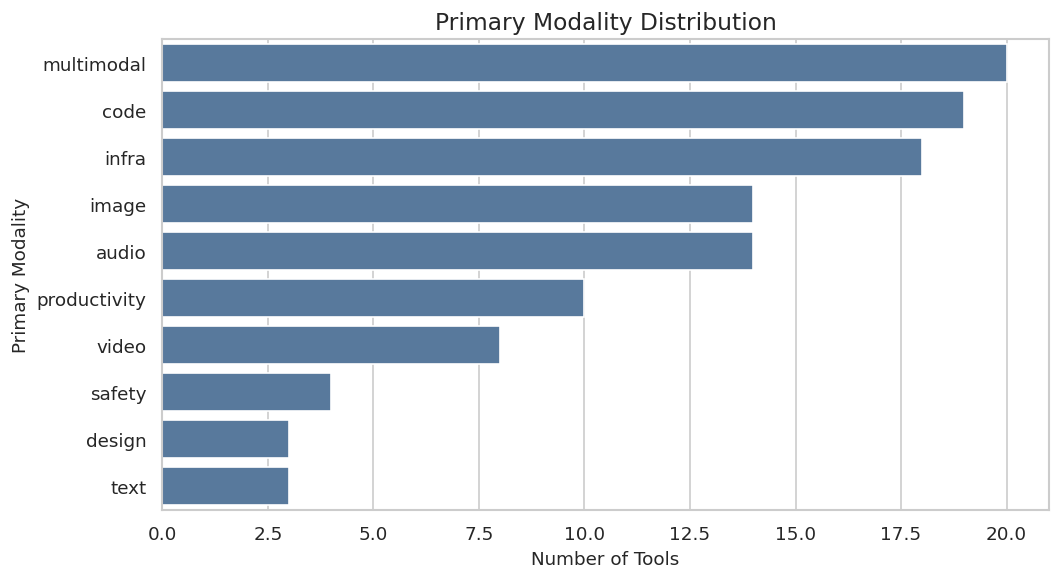

**Insight:** `multimodal` is the most common primary modality label. The modality field behaves like a primary classification rather than a detailed multi-capability map.

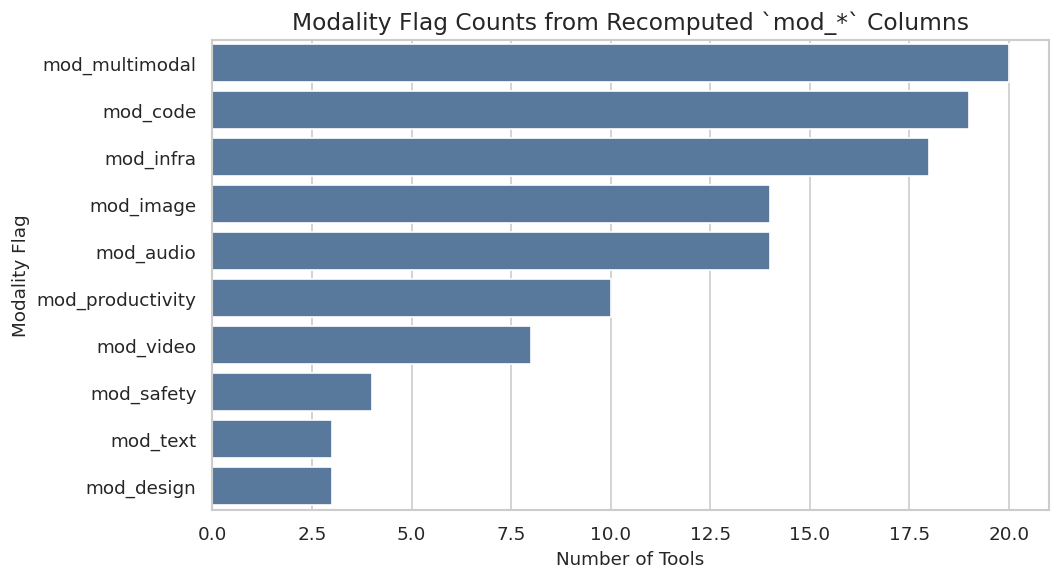

**Insight:** 100.0% of rows have exactly one active modality flag. Because the flags are mostly one-hot, co-occurrence claims are not supported by this dataset.

In [67]:
if "modality_canonical" in df.columns:
    modality_counts = df["modality_canonical"].value_counts()

    plt.figure(figsize=(9, 5))
    ax = sns.barplot(x=modality_counts.values, y=modality_counts.index, color=PRIMARY_COLOR)
    ax.set_title("Primary Modality Distribution")
    ax.set_xlabel("Number of Tools")
    ax.set_ylabel("Primary Modality")
    plt.tight_layout()
    plt.show()

    display(Markdown(
        f"**Insight:** `{modality_counts.index[0]}` is the most common primary modality label. "
        "The modality field behaves like a primary classification rather than a detailed multi-capability map."
    ))

if mod_cols:
    modality_flag_counts = df[mod_cols].sum().sort_values(ascending=False)

    plt.figure(figsize=(9, 5))
    ax = sns.barplot(x=modality_flag_counts.values, y=modality_flag_counts.index, color=PRIMARY_COLOR)
    ax.set_title("Modality Flag Counts from Recomputed `mod_*` Columns")
    ax.set_xlabel("Number of Tools")
    ax.set_ylabel("Modality Flag")
    plt.tight_layout()
    plt.show()

    one_flag_share = (df["modality_count_recomputed"] == 1).mean()
    display(Markdown(
        f"**Insight:** {one_flag_share:.1%} of rows have exactly one active modality flag. "
        "Because the flags are mostly one-hot, co-occurrence claims are not supported by this dataset."
    ))

## Modeling Setup

The modeling section is leak-aware and uses reusable metadata.

Excluded identifier-like fields:

- `tool_name`
- `company`
- `website`
- `source_domain`

These fields identify specific tools or publishers directly, so they are excluded from the baseline feature set.

In [68]:
required_columns = {TARGET, "category_canonical", "modality_canonical"}
missing_required = sorted(required_columns - set(df.columns))
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

categorical_features = [
    col for col in ["category_canonical", "modality_canonical", "api_status"]
    if col in df.columns
]

numeric_features = [
    col for col in [
        "api_available",
        "release_year",
        "years_since_release_2025",
        "is_recent_release",
        "modality_count_recomputed",
    ] + mod_cols
    if col in df.columns
]

feature_columns = categorical_features + numeric_features

X = df[feature_columns].copy()
y = df[TARGET].astype(int)

display(Markdown("### Feature Set"))
display(pd.DataFrame({
    "feature": feature_columns,
    "type": ["categorical" if col in categorical_features else "numeric" for col in feature_columns],
}))

display(Markdown(
    f"Training target: `{TARGET}`. Positive class = open source. "
    f"Rows available: {len(df):,}. Positive class share: {y.mean():.1%}."
))

### Feature Set

,feature,type
0,category_canonical,categorical
1,modality_canonical,categorical
2,api_status,categorical
3,api_available,numeric
4,release_year,numeric
5,years_since_release_2025,numeric
6,is_recent_release,numeric
7,modality_count_recomputed,numeric
8,mod_text,numeric
9,mod_image,numeric


Training target: `open_source`. Positive class = open source. Rows available: 113. Positive class share: 37.2%.

## Cross-Validated Baselines

Stratified cross-validation is used to compare models more reliably than a single split. A dummy majority baseline is included to check whether reusable metadata adds useful signal.

,model,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,roc_auc_mean,roc_auc_std,avg_precision_mean,avg_precision_std
0,Logistic Regression,0.611,0.048,0.599,0.049,0.675,0.061,0.588,0.079
1,Gradient Boosting,0.655,0.031,0.530,0.047,0.636,0.094,0.572,0.053
2,Random Forest,0.549,0.049,0.519,0.054,0.603,0.085,0.486,0.060
3,Dummy majority,0.628,0.017,0.386,0.006,0.500,0.000,0.372,0.017


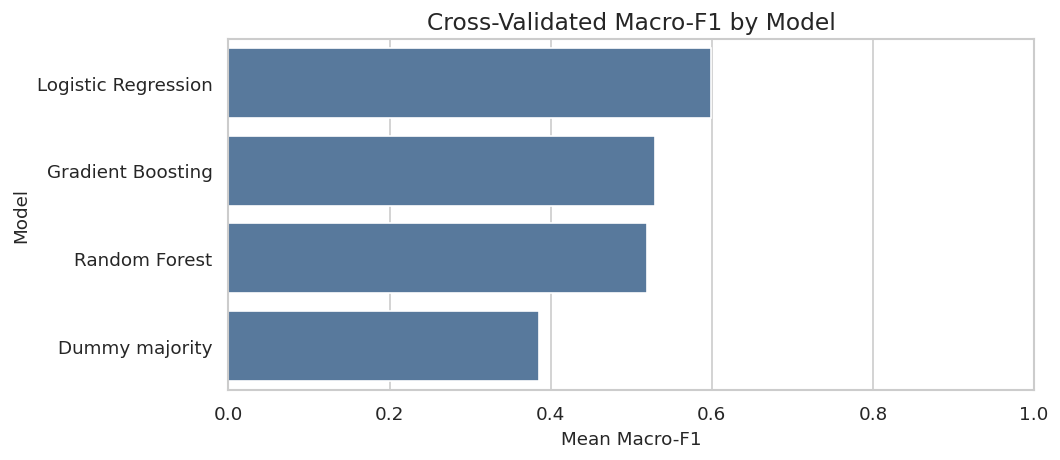

**Modeling insight:** `Logistic Regression` has the highest mean CV macro-F1 (0.599), compared with the dummy baseline at 0.386. The lift exists, but it is modest and should be treated as exploratory.

In [69]:
try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", encoder),
        ]), categorical_features),
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
        ]), numeric_features),
    ],
    remainder="drop",
)

models = {
    "Dummy majority": Pipeline([
        ("prep", preprocess),
        ("clf", DummyClassifier(strategy="most_frequent")),
    ]),
    "Logistic Regression": Pipeline([
        ("prep", preprocess),
        ("clf", LogisticRegression(
            max_iter=1_000,
            class_weight="balanced",
            random_state=RANDOM_SEED,
        )),
    ]),
    "Random Forest": Pipeline([
        ("prep", preprocess),
        ("clf", RandomForestClassifier(
            n_estimators=150,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=RANDOM_SEED,
        )),
    ]),
    "Gradient Boosting": Pipeline([
        ("prep", preprocess),
        ("clf", GradientBoostingClassifier(
            n_estimators=80,
            learning_rate=0.05,
            max_depth=2,
            random_state=RANDOM_SEED,
        )),
    ]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
scoring = {
    "accuracy": "accuracy",
    "macro_f1": "f1_macro",
    "roc_auc": "roc_auc",
    "avg_precision": "average_precision",
}

cv_rows = []

for model_name, model in models.items():
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        error_score=np.nan,
    )

    row = {"model": model_name}
    for metric in scoring:
        values = scores[f"test_{metric}"]
        row[f"{metric}_mean"] = float(np.nanmean(values))
        row[f"{metric}_std"] = float(np.nanstd(values))
    cv_rows.append(row)

cv_results = (
    pd.DataFrame(cv_rows)
    .sort_values("macro_f1_mean", ascending=False)
    .reset_index(drop=True)
)

display(cv_results.style.format({
    "accuracy_mean": "{:.3f}",
    "accuracy_std": "{:.3f}",
    "macro_f1_mean": "{:.3f}",
    "macro_f1_std": "{:.3f}",
    "roc_auc_mean": "{:.3f}",
    "roc_auc_std": "{:.3f}",
    "avg_precision_mean": "{:.3f}",
    "avg_precision_std": "{:.3f}",
}))

plt.figure(figsize=(9, 4))
ax = sns.barplot(data=cv_results, x="macro_f1_mean", y="model", color=PRIMARY_COLOR)
ax.set_title("Cross-Validated Macro-F1 by Model")
ax.set_xlabel("Mean Macro-F1")
ax.set_ylabel("Model")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

best_model_name = cv_results.iloc[0]["model"]
best_cv_f1 = cv_results.iloc[0]["macro_f1_mean"]
dummy_f1 = cv_results.loc[cv_results["model"] == "Dummy majority", "macro_f1_mean"].iloc[0]

display(Markdown(
    f"**Modeling insight:** `{best_model_name}` has the highest mean CV macro-F1 "
    f"({best_cv_f1:.3f}), compared with the dummy baseline at {dummy_f1:.3f}. "
    "The lift exists, but it is modest and should be treated as exploratory."
))

## Hold-Out Sanity Check

This section fits the best cross-validated baseline on a single stratified train/test split. It is a final sanity check for the notebook workflow.

### Best CV Model: `Logistic Regression`

,value
accuracy,0.609
macro_f1,0.606
precision_open,0.500
recall_open,0.667
roc_auc,0.635
average_precision,0.511


### Classification Report

,precision,recall,f1-score,support
closed_source,0.727,0.571,0.640,14.000
open_source,0.500,0.667,0.571,9.000
accuracy,0.609,0.609,0.609,0.609
macro avg,0.614,0.619,0.606,23.000
weighted avg,0.638,0.609,0.613,23.000


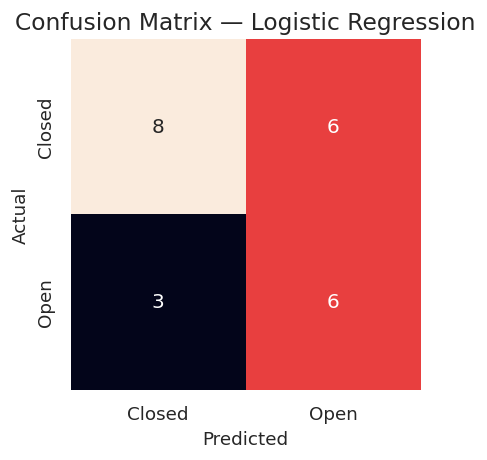

**Interpretation:** This baseline exposes weak metadata signals, but the dataset is too small for strong predictive claims. Use the model as an exploratory benchmark, not as a reliable classifier.

In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_SEED,
)

best_model = clone(models[best_model_name])
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

if hasattr(best_model.named_steps["clf"], "predict_proba"):
    y_proba = best_model.predict_proba(X_test)[:, 1]
else:
    y_proba = None

holdout_metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "macro_f1": f1_score(y_test, y_pred, average="macro", zero_division=0),
    "precision_open": precision_score(y_test, y_pred, zero_division=0),
    "recall_open": recall_score(y_test, y_pred, zero_division=0),
}

if y_proba is not None and y_test.nunique() == 2:
    holdout_metrics["roc_auc"] = roc_auc_score(y_test, y_proba)
    holdout_metrics["average_precision"] = average_precision_score(y_test, y_proba)

display(Markdown(f"### Best CV Model: `{best_model_name}`"))
display(pd.DataFrame.from_dict(holdout_metrics, orient="index", columns=["value"]).style.format("{:.3f}"))

report = classification_report(
    y_test,
    y_pred,
    target_names=["closed_source", "open_source"],
    output_dict=True,
    zero_division=0,
)

display(Markdown("### Classification Report"))
display(pd.DataFrame(report).T.style.format("{:.3f}"))

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

plt.figure(figsize=(5, 4))
ax = sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cbar=False,
    square=True,
    xticklabels=["Closed", "Open"],
    yticklabels=["Closed", "Open"],
)
ax.set_title(f"Confusion Matrix — {best_model_name}")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

display(Markdown(
    "**Interpretation:** This baseline shows that simple metadata features carry some signal, "
    "but the dataset size and feature scope are not enough for strong predictive claims. "
    "Use the model as an exploratory benchmark, not as a reliable classifier."
))

## Feature Signal Check

Permutation importance is computed on the hold-out split. Treat the ranking as directional rather than definitive.

,feature,importance_mean,importance_std
0,mod_text,0.0455,0.0340
1,mod_code,0.0447,0.0426
2,category_canonical,0.0334,0.0430
3,mod_safety,0.0267,0.0342
4,modality_canonical,0.0178,0.0344
5,mod_multimodal,0.0112,0.0343
6,api_available,0.0056,0.0244
7,api_status,0.0048,0.0144
8,years_since_release_2025,0.0048,0.0348
9,release_year,0.0048,0.0348


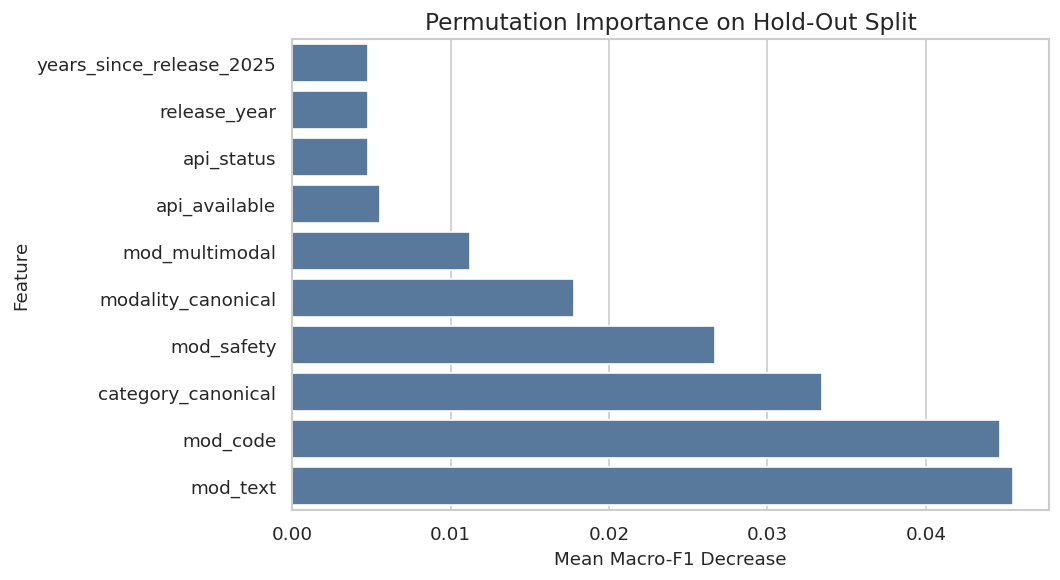

**Insight:** Feature importance is useful for inspection, but it should not be overread. A different small split can change the ranking.

In [71]:
if best_model_name != "Dummy majority":
    perm = permutation_importance(
        best_model,
        X_test,
        y_test,
        n_repeats=10,
        random_state=RANDOM_SEED,
        scoring="f1_macro",
        n_jobs=1,
    )

    importance_df = (
        pd.DataFrame({
            "feature": feature_columns,
            "importance_mean": perm.importances_mean,
            "importance_std": perm.importances_std,
        })
        .sort_values("importance_mean", ascending=False)
        .reset_index(drop=True)
    )

    display(importance_df.style.format({
        "importance_mean": "{:.4f}",
        "importance_std": "{:.4f}",
    }))

    plot_df = importance_df.head(10).sort_values("importance_mean")

    plt.figure(figsize=(9, 5))
    ax = sns.barplot(data=plot_df, x="importance_mean", y="feature", color=PRIMARY_COLOR)
    ax.set_title("Permutation Importance on Hold-Out Split")
    ax.set_xlabel("Mean Macro-F1 Decrease")
    ax.set_ylabel("Feature")
    plt.tight_layout()
    plt.show()

    display(Markdown(
        "**Insight:** Feature importance is useful for inspection, but it should not be overread. "
        "A different small split can change the ranking."
    ))
else:
    display(Markdown("Permutation importance is skipped because the best model is the dummy baseline."))

## Decisions and Takeaways

- The dataset is clean in the basic sense: no missing values, no duplicate rows, and no duplicate tool names.
- The original `modality_count` is inconsistent with the `mod_*` flags, so analysis should use the recomputed version.
- The catalog is concentrated in a few categories, especially LLM/chat tools, with a long tail of smaller categories.
- API availability is very high in this dataset, so API access is not a strong separator by itself.
- Modality flags behave mostly as a one-hot primary label, so this dataset does not support strong modality co-occurrence claims.
- Open-source prediction from high-level metadata carries some signal, but the baseline should be treated as an exploratory benchmark.

## Summary and Next Steps

This notebook provides a Kaggle-friendly workflow that:

- Audits the dataset before visualization.
- Fixes the inconsistent `modality_count` logic.
- Avoids unsupported claims about modality co-occurrence.
- Uses leak-aware baseline features instead of identifiers.
- Treats the modeling signal as exploratory.

The result is a clean exploratory workflow for understanding the catalog structure and testing whether simple metadata carries useful signal.

## Appendix — Data Dictionary

| Field | Meaning |
|---|---|
| `tool_name` | Name of the tool or platform |
| `company` | Publisher, company, or project owner |
| `category_canonical` | Standardized category label |
| `modality_canonical` | Primary modality label |
| `open_source` | Binary label; 1 means open source, 0 means closed source |
| `api_available` | Whether API access is available |
| `api_status` | Text label for API availability |
| `website` | Main website or project page |
| `source_domain` | Domain extracted from the source URL |
| `release_year` | First public release year |
| `years_since_release_2025` | Derived age using 2025 as the reference year |
| `mod_*` | Binary modality flags |
| `modality_count_original` | Original `modality_count` preserved for audit |
| `modality_count_recomputed` | Reliable modality count derived from active `mod_*` flags |